# Simple Linear Regression – Marketing ROI Analysis

In [8]:
import pandas as pd
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

In [13]:
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


In [15]:
df.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [18]:
df.isnull().sum()

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [21]:
df_clean = df.dropna()
df_clean.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [22]:
df_clean.shape

(4546, 4)

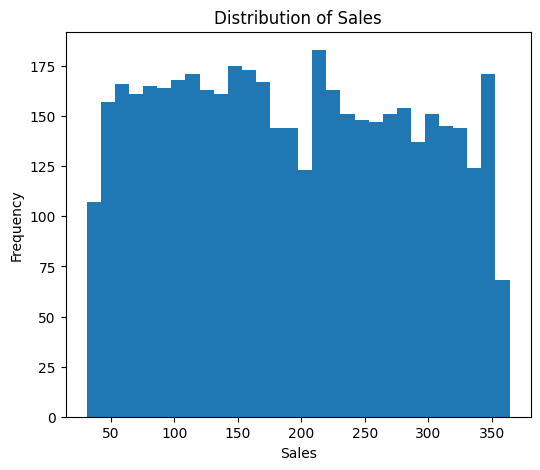

In [62]:
plt.figure(figsize=(6,5))

plt.hist(df_clean["Sales"], bins=30)

plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.title("Distribution of Sales")

plt.show()

### Distribution of Sales

The histogram shows the distribution of Sales values in the dataset. Most sales values are concentrated around the center of the distribution with fewer observations at the sides.

In [23]:
correlation_matrix = df_clean.corr()
print(correlation_matrix)

                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


In [24]:
correlation_matrix["Sales"]

TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64

In [26]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


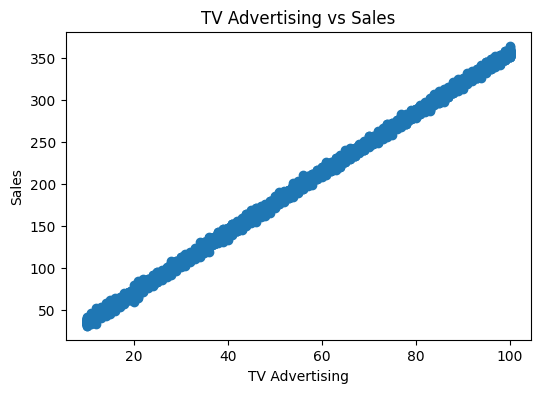

In [59]:
plt.figure(figsize=(6,4))

plt.scatter(df_clean["TV"], df_clean["Sales"])

plt.xlabel("TV Advertising")
plt.ylabel("Sales")


plt.title("TV Advertising vs Sales")

plt.show()


In [39]:
X = df_clean["TV"]
y = df_clean["Sales"]

In [ ]:
import statsmodels.api as sm

Statsmodels installed successfully


In [47]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [48]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:49:11   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

### OLS Regression Interpretation

- The model has an R-squared value of 0.999, showing that approximately 99.9% of the variation in Sales is explained by TV advertising.
- The coefficient for TV advertising is 3.5615, meaning that a one-unit increase in TV advertising is linked with an average increase of approximately 3.56 units in Sales.
- The p-value for TV advertising is less than 0.05 (0.000), indicating that TV advertising is a significant predictor of Sales.
- Therefore, TV advertising is the strongest marketing channel for predicting sales performance in this dataset.

In [50]:
predictions = model.predict(X)

residuals = model.resid

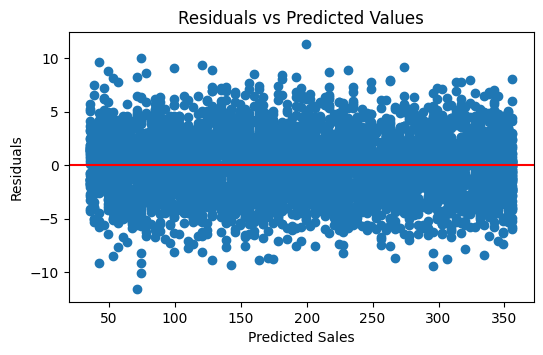

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3.5))

plt.scatter(predictions, residuals)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

### Diagnostic Plot: Residuals vs Predicted Values

The residuals are randomly distributed around the zero or red mid line with no obvious pattern or curving. The spread of residuals remains relatively constant across predicted values.

Interpretation:
- The linearity and homoscedasticity assumptions are satisfied.
- The Simple Linear Regression model is appropriate for the given dataset.

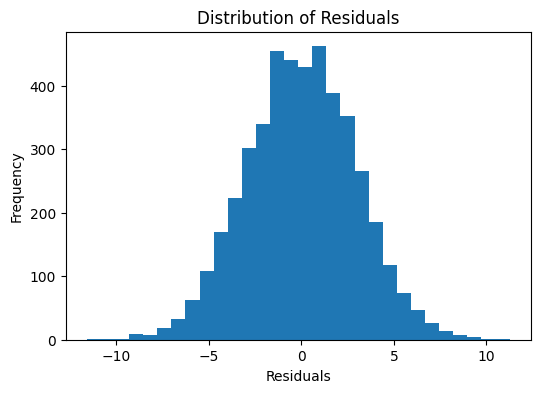

In [57]:
plt.figure(figsize=(6,4))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

### Diagnostic Plot: Distribution of Residuals

The histogram of residuals shows an approximately bell-shaped and symmetrical distribution centered around zero.

Interpretation:
- The residuals or noise appeared normally distributed and the normality assumption for Simple Linear Regression is satisfied.
- Therefore, the regression model meets the key assumptions required for valid statistical inference.

## Marketing ROI Recommendation

Based on the correlation analysis and OLS regression results, TV advertising is the strongest predictor of Sales.

Key findings:
- TV advertising has the highest correlation with Sales (0.9995).
- The regression model achieved an R-squared value of 0.999.
- The TV coefficient is 3.5615, indicating that each additional unit spent on TV advertising increases Sales by approximately 3.56 units.
- The p-value is less than 0.05, confirming that TV advertising has a statistically significant impact on Sales.

Recommendation:

The company should prioritize TV advertising when allocating marketing budgets because it demonstrates the strongest relationship with Sales and provides the highest expected return on investment (ROI) among other marketing channels.

In [55]:
model.params

const   -0.132493
TV       3.561514
dtype: float64

## Final Regression Equation

The fitted Simple Linear Regression model is:

Sales = -0.132493(intercept) + 3.561514(TV)

Interpretation:
- The intercept is -0.132493.
- For every one-unit increase in TV advertising, Sales increase by approximately 3.56 units.
- The positive coefficient confirms a strong positive relationship between TV advertising and Sales.